# Reading the data and importing libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

path = r'C:\Users\osber\Desktop\AI MS\AusApparalSales4thQrt2020.csv'
df = pd.read_csv(path)
print('Rows, columns:', df.shape)
df.head()

Rows, columns: (7560, 6)


,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [28]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    7560 non-null   str  
 1   Time    7560 non-null   str  
 2   State   7560 non-null   str  
 3   Group   7560 non-null   str  
 4   Unit    7560 non-null   int64
 5   Sales   7560 non-null   int64
dtypes: int64(2), str(4)
memory usage: 354.5 KB
None


In [29]:
print(df.describe())

              Unit          Sales
count  7560.000000    7560.000000
mean     18.005423   45013.558201
std      12.901403   32253.506944
min       2.000000    5000.000000
25%       8.000000   20000.000000
50%      14.000000   35000.000000
75%      26.000000   65000.000000
max      65.000000  162500.000000


Data Wrangling

# Checking for missing data or bad/incorrect values

In [30]:
# Check missing values
print(df.isna().sum())

# Check non-null counts
print(df.notna().sum())

# Check duplicate rows
print(df.duplicated().sum())  


Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64
Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64
0


Data Cleaning 

In [31]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df_clean = df.copy()

In [32]:
# Normalize numeric columns
numeric_cols = ['Unit', 'Sales']

# Standard scaling: mean 0, std 1
scaled_df = df.copy()
scaled_df[numeric_cols] = (scaled_df[numeric_cols] - scaled_df[numeric_cols].mean()) / scaled_df[numeric_cols].std()

print('Standardized columms:')
print(scaled_df[numeric_cols].head())
print('\nSummary of standardized columns:')
print(scaled_df[numeric_cols].describe())


Standardized columms:
       Unit     Sales
0 -0.775530 -0.775530
1 -0.775530 -0.775530
2 -1.085574 -1.085574
3 -0.232953 -0.232953
4 -1.163085 -1.163085

Summary of standardized columns:
               Unit         Sales
count  7.560000e+03  7.560000e+03
mean   4.511382e-17  3.007588e-17
std    1.000000e+00  1.000000e+00
min   -1.240596e+00 -1.240596e+00
25%   -7.755299e-01 -7.755299e-01
50%   -3.104642e-01 -3.104642e-01
75%    6.196672e-01  6.196672e-01
max    3.642594e+00  3.642594e+00


In [33]:
# Aggregate sales by state using pandas

state_sales = df_clean.groupby('State')['Sales'].sum()
group_sales = df_clean.groupby('Group')['Sales'].sum()
print(state_sales)
print(group_sales)


State
NSW     74970000
NT      22580000
QLD     33417500
SA      58857500
TAS     22760000
VIC    105565000
WA      22152500
Name: Sales, dtype: int64
Group
Kids       85072500
Men        85750000
Seniors    84037500
Women      85442500
Name: Sales, dtype: int64


In [34]:
# Descriptive Statistics Analysis

print("Summary statistics for 'Unit' column:")
print(df['Unit'].describe())
print("\n Summary statistics for 'Sales' column: \n")
print(df['Sales'].describe())

Summary statistics for 'Unit' column:
count    7560.000000
mean       18.005423
std        12.901403
min         2.000000
25%         8.000000
50%        14.000000
75%        26.000000
max        65.000000
Name: Unit, dtype: float64

 Summary statistics for 'Sales' column: 

count      7560.000000
mean      45013.558201
std       32253.506944
min        5000.000000
25%       20000.000000
50%       35000.000000
75%       65000.000000
max      162500.000000
Name: Sales, dtype: float64


In [35]:
# Descriptive Group Stats

df_group_sales = df.groupby('Group')['Sales'].sum()
print("\n Total sales by group: \n")
print(df_group_sales)

print("\n Group with Highest Sales:", df_group_sales.idxmax(), "with Sales:", df_group_sales.max())

print("\n Group with Lowest Sales:", df_group_sales.idxmin(), "with Sales:", df_group_sales.min())


 Total sales by group: 

Group
Kids       85072500
Men        85750000
Seniors    84037500
Women      85442500
Name: Sales, dtype: int64

 Group with Highest Sales:  Men with Sales: 85750000

 Group with Lowest Sales:  Seniors with Sales: 84037500



Total sales by month:

      Month      Sales
0   October  114290000
1  November   90682500
2  December  135330000

Total sales by day of week:

   DayOfWeek     Sales
0     Monday  48050000
1    Tuesday  50327500
2  Wednesday  49945000
3   Thursday  49405000
4     Friday  48000000
5   Saturday  46245000
6     Sunday  48330000


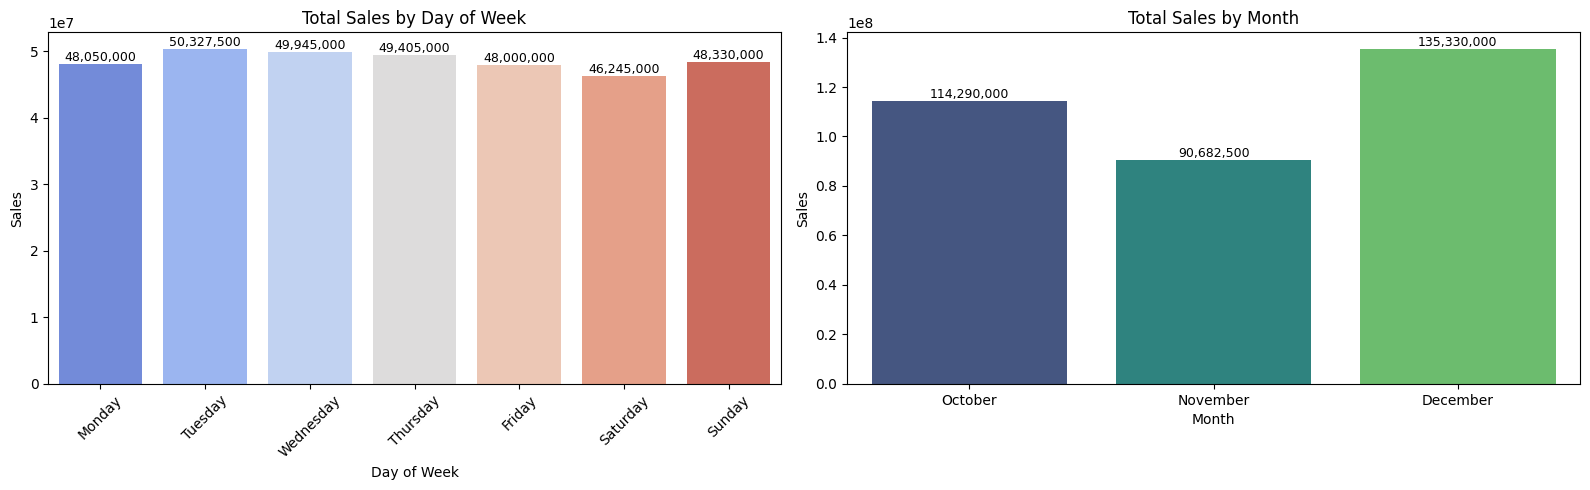

In [37]:
# Grouped Data for Monthly & Quarterly Reports

df['Month'] = df['Date'].dt.month_name()
df['DayOfWeek'] = df['Date'].dt.day_name()

monthly_sales = df.groupby('Month', as_index=False)['Sales'].sum()
order_months = ['October', 'November', 'December']
monthly_sales = monthly_sales.set_index('Month').reindex(order_months).reset_index()

dayofweek_sales = df.groupby('DayOfWeek', as_index=False)['Sales'].sum()
order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dayofweek_sales = dayofweek_sales.set_index('DayOfWeek').reindex(order_days).reset_index()

print("\nTotal sales by month:\n")
print(monthly_sales)
print("\nTotal sales by day of week:\n")
print(dayofweek_sales)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=dayofweek_sales, x='DayOfWeek', y='Sales', ax=axes[0], palette='coolwarm', order=order_days)
axes[0].set_title('Total Sales by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Sales')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

sns.barplot(data=monthly_sales, x='Month', y='Sales', ax=axes[1], palette='viridis', order=order_months)
axes[1].set_title('Total Sales by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Sales')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


Total sales by month:

      Month      Sales
0   October  114290000
1  November   90682500
2  December  135330000

Total sales by day of week:

   DayOfWeek     Sales
0     Monday  48050000
1    Tuesday  50327500
2  Wednesday  49945000
3   Thursday  49405000
4     Friday  48000000
5   Saturday  46245000
6     Sunday  48330000

Total sales by quarter:

  Quarter      Sales
0  2020Q4  340302500


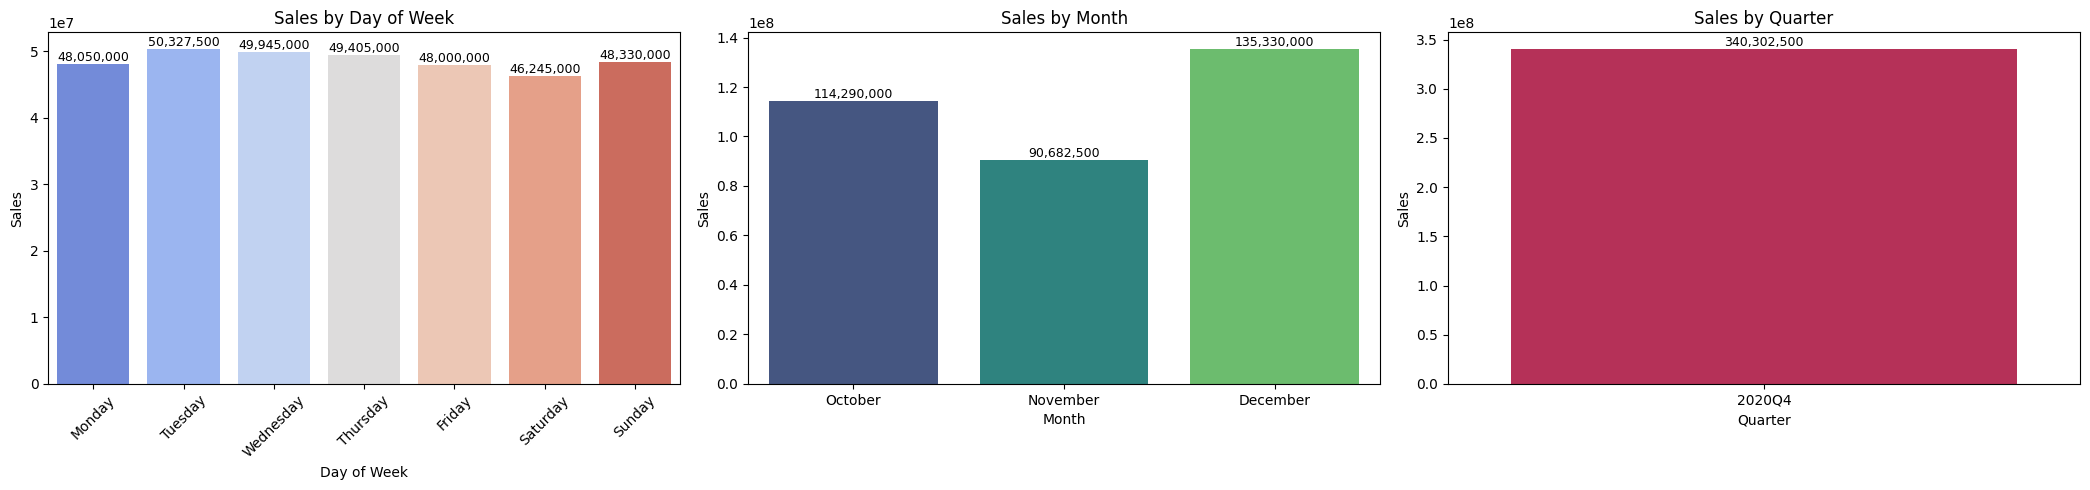

In [38]:
# Combined weekly, monthly, and quarterly sales report using seaborn

df['Month'] = df['Date'].dt.month_name()
df['DayOfWeek'] = df['Date'].dt.day_name()

monthly_sales = df.groupby('Month', as_index=False)['Sales'].sum()
order_months = ['October', 'November', 'December']
monthly_sales = monthly_sales.set_index('Month').reindex(order_months).reset_index()

dayofweek_sales = df.groupby('DayOfWeek', as_index=False)['Sales'].sum()
order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dayofweek_sales = dayofweek_sales.set_index('DayOfWeek').reindex(order_days).reset_index()

quarterly_sales = df.set_index('Date').resample('QE')['Sales'].sum().reset_index()
quarterly_sales['Quarter'] = quarterly_sales['Date'].dt.to_period('Q').astype(str)

print("\nTotal sales by month:\n")
print(monthly_sales)
print("\nTotal sales by day of week:\n")
print(dayofweek_sales)
print("\nTotal sales by quarter:\n")
print(quarterly_sales[['Quarter', 'Sales']])

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

sns.barplot(data=dayofweek_sales, x='DayOfWeek', y='Sales', ax=axes[0], palette='coolwarm', order=order_days, ci=None)
axes[0].set_title('Sales by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Sales')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

sns.barplot(data=monthly_sales, x='Month', y='Sales', ax=axes[1], palette='viridis', order=order_months, ci=None)
axes[1].set_title('Sales by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Sales')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

sns.barplot(data=quarterly_sales, x='Quarter', y='Sales', ax=axes[2], palette='rocket', ci=None)
axes[2].set_title('Sales by Quarter')
axes[2].set_xlabel('Quarter')
axes[2].set_ylabel('Sales')
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

<Axes: title={'center': 'Total Sales by State and Group'}, xlabel='State,Group'>

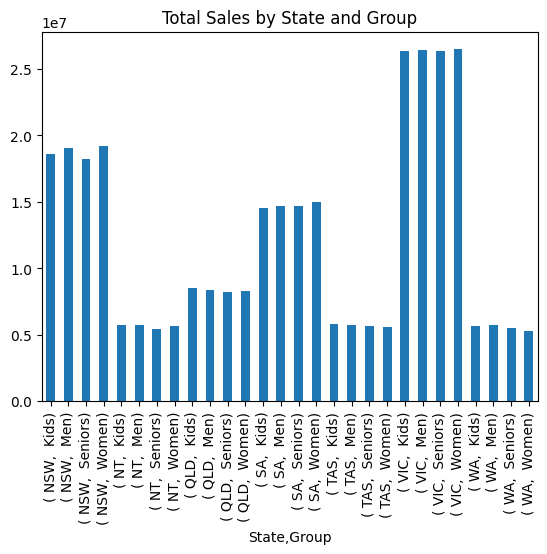

In [39]:
# Data Visualization: Total Sales by State and Group (State-wise-sales analysis)
df.groupby(['State', 'Group'])['Sales'].sum().plot(kind='bar', title='Total Sales by State and Group')

<Axes: title={'center': 'Total Sales by State and Group'}, xlabel='Group,State'>

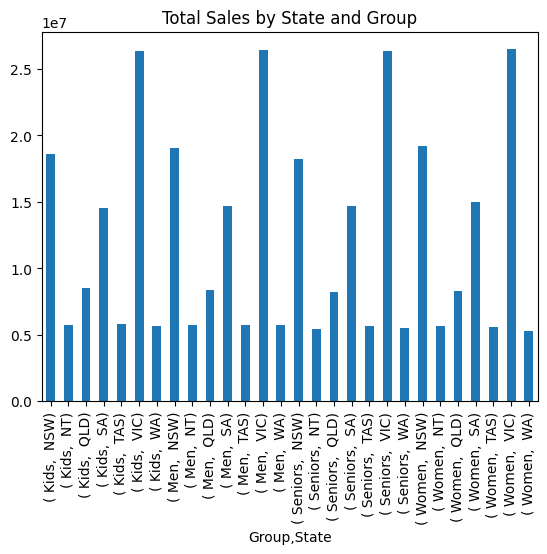

In [40]:
df.groupby(['Group', 'State'])['Sales'].sum().plot(kind='bar', title='Total Sales by State and Group')

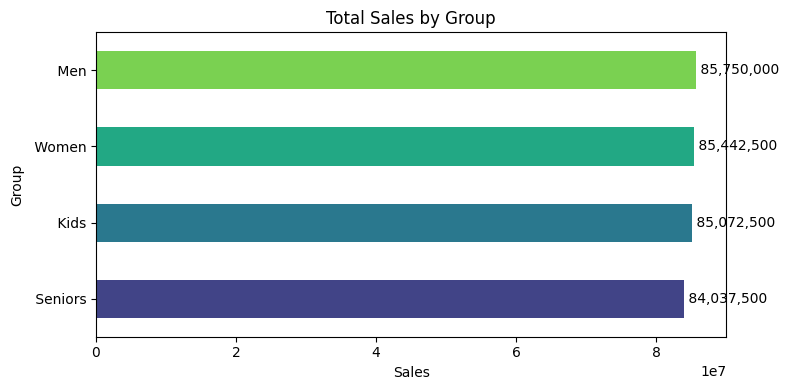

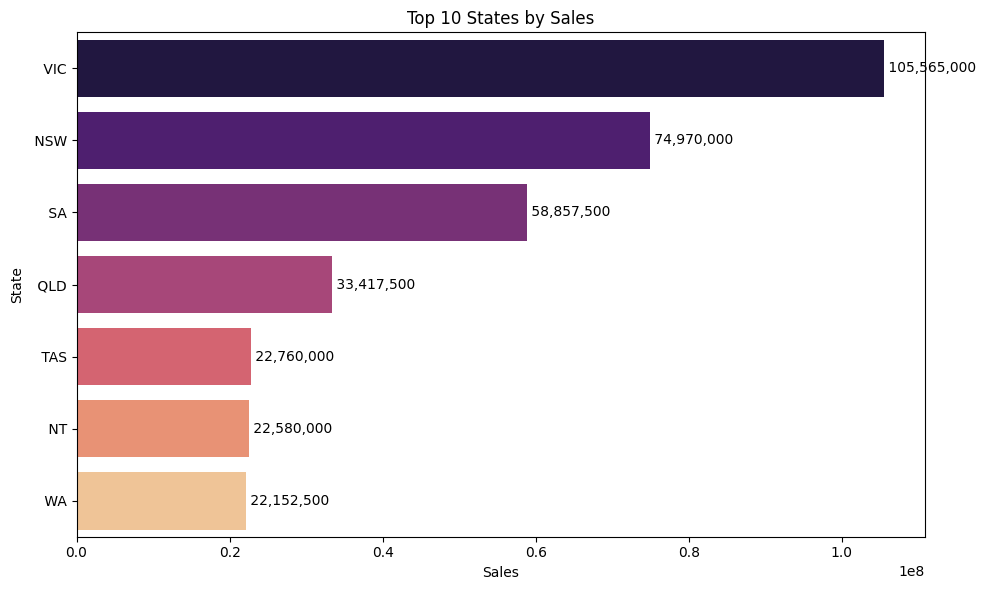

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Improved Group sales horizontal bar chart
df_group_sales = df.groupby('Group')['Sales'].sum().sort_values(ascending=True)
plt.figure(figsize=(8, 4))
df_group_sales.plot(kind='barh', color=sns.color_palette('viridis', len(df_group_sales)))
plt.title('Total Sales by Group')
plt.xlabel('Sales')
for i, v in enumerate(df_group_sales):
    plt.text(v, i, f' {v:,.0f}', va='center')
plt.tight_layout()
plt.show()

# Improved State sales (top 10) bar chart
plt.figure(figsize=(10, 6))
state_sales = df.groupby('State', as_index=False)['Sales'].sum().sort_values(by='Sales', ascending=False)
top_states = state_sales.head(10).set_index('State')['Sales']
sns.barplot(x=top_states.values, y=top_states.index, palette='magma')
plt.title('Top 10 States by Sales')
plt.xlabel('Sales')
for i, v in enumerate(top_states.values):
    plt.text(v, i, f' {v:,.0f}', va='center')
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

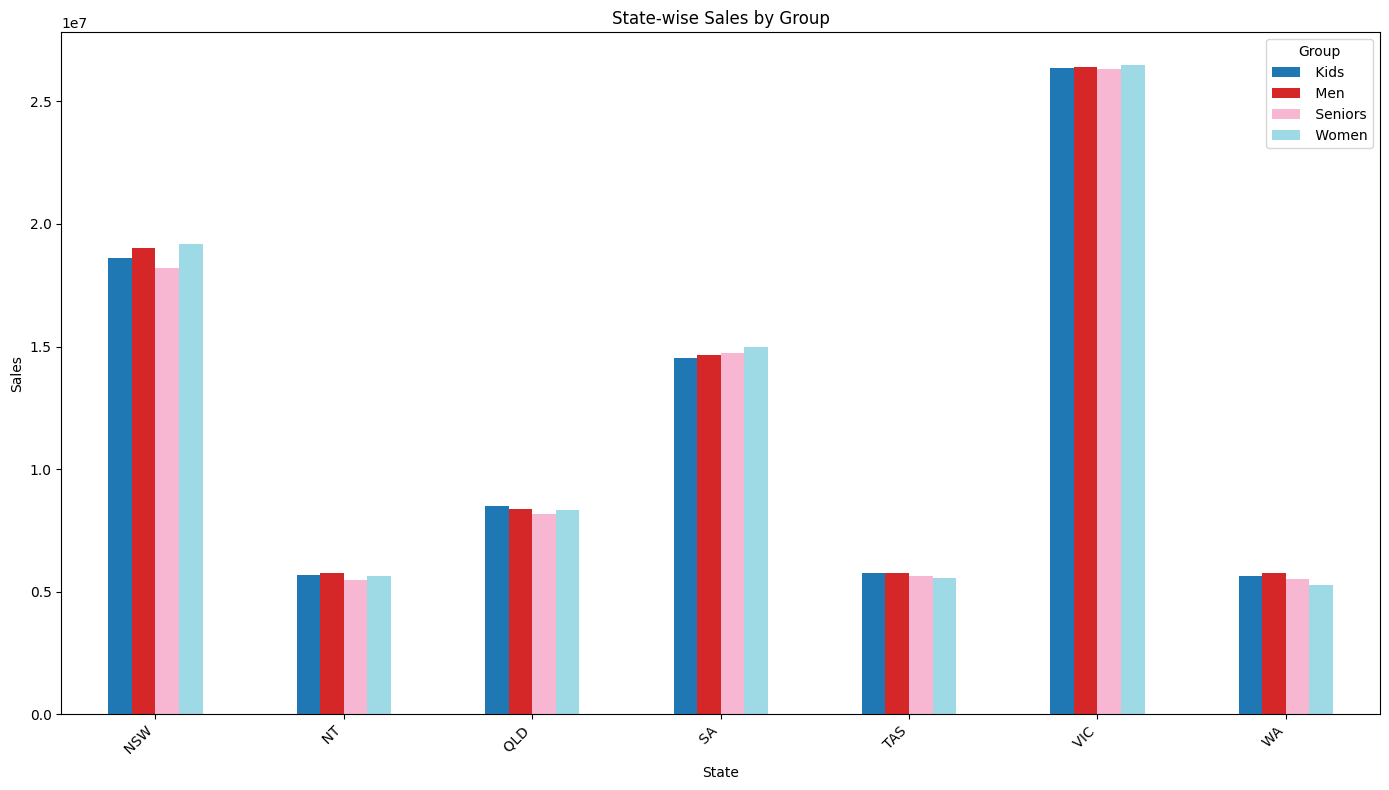

In [42]:
# State-wise group sales plot
plt.figure(figsize=(14, 8))
state_group_sales = df.groupby(['State', 'Group'])['Sales'].sum().reset_index()
pivot = state_group_sales.pivot(index='State', columns='Group', values='Sales').fillna(0)
pivot.plot(kind='bar', stacked=False, figsize=(14, 8), colormap='tab20')
plt.title('State-wise Sales by Group')
plt.xlabel('State')
plt.ylabel('Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(title='Group')
plt.show()

Time of the day analysis

<Figure size 1400x800 with 0 Axes>

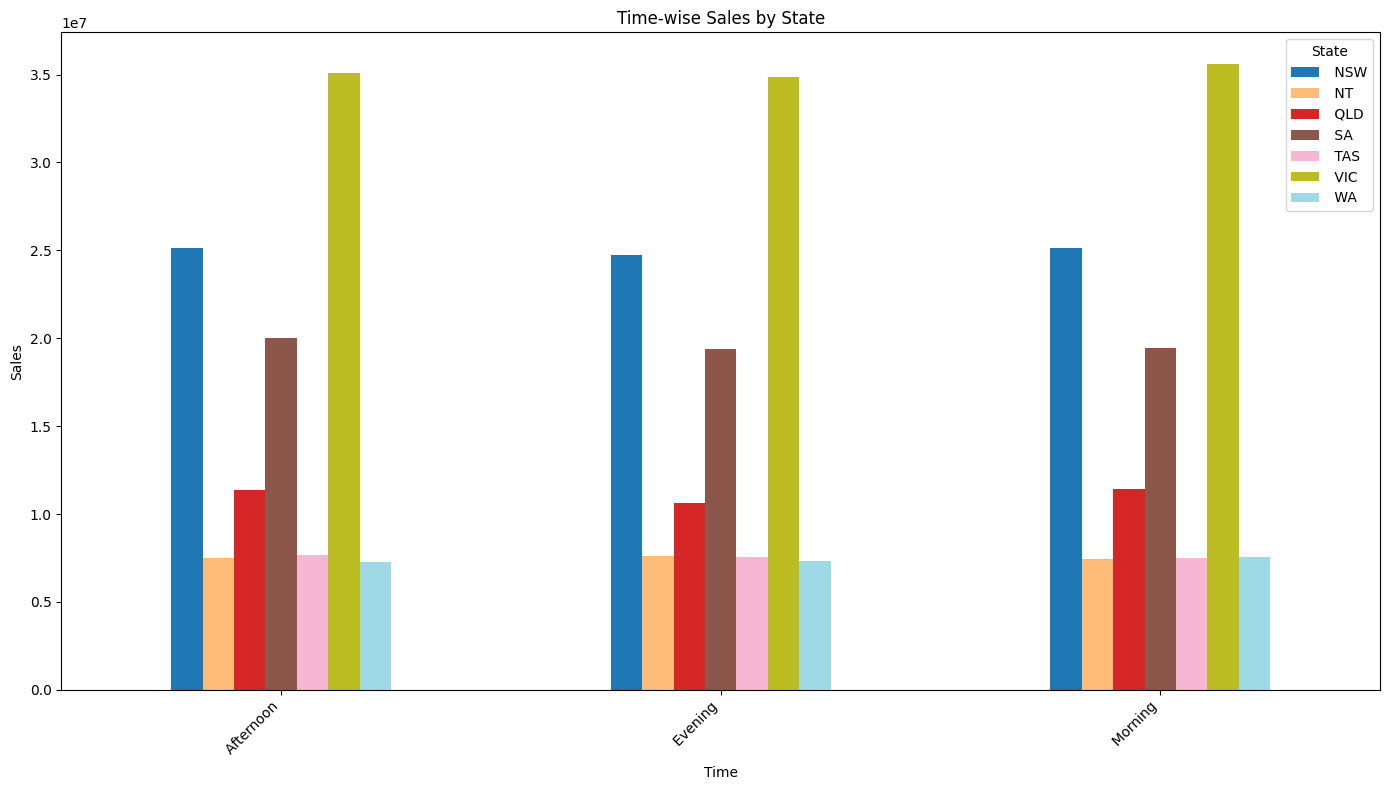

In [43]:
# State-wise group sales plot
plt.figure(figsize=(14, 8))
state_group_sales = df.groupby(['Time', 'State'])['Sales'].sum().reset_index()
pivot = state_group_sales.pivot(index='Time', columns='State', values='Sales').fillna(0)
pivot.plot(kind='bar', stacked=False, figsize=(14, 8), colormap='tab20')
plt.title('Time-wise Sales by State')
plt.xlabel('Time')
plt.ylabel('Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(title='State')
plt.show()